In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## 3A

In [102]:
from random import gauss


def laplace(img: cv2.typing.MatLike):
    laplacian_filter = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]])
    float_img = cv2.filter2D(img, cv2.CV_32F, laplacian_filter)
    converted_img = ((float_img+1020)/2040*255)
    return converted_img

def sobel_x(img: cv2.typing.MatLike):
    filter = np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]])
    
    float_img = cv2.filter2D(img, cv2.CV_32F, filter)
    x, y = img.shape
    converted_img = (((float_img+1020)/2040)*255)
    return converted_img

def sobel_y(img: cv2.typing.MatLike):
    filter = np.array([
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]])
    float_img = cv2.filter2D(img, cv2.CV_32F, filter)
    x, y = img.shape
    converted_img = (((float_img+1020)/2040)*255)
    return converted_img

def sobel_limiar(img: cv2.typing.MatLike, limiar):
    dx = sobel_x(img).astype(np.float32)
    dy = sobel_y(img).astype(np.float32)
    x, y = img.shape
    magnitude_map = np.sqrt(dx**2 + dy**2)/np.sqrt(2)
    print(magnitude_map)
    limiar_img = np.where(magnitude_map > limiar, 255, 0).astype(np.uint8)
    return limiar_img

def sobel_limiar_implemented(img, limiar):
    dx = cv2.Sobel(img, cv2.CV_32F, 1, 0)
    dy = cv2.Sobel(img, cv2.CV_32F, 0, 1)
    magnitude = np.sqrt(dx**2 + dy**2)
    normalized = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX) # type: ignore
    res = np.where(normalized > limiar, 255, 0)
    return res    

def canny_detect(img, low, high):
    gaussian = cv2.GaussianBlur(img, (3, 3), 1.5, None) # type: ignore
    edges = cv2.Canny(gaussian, low, high)
    return edges


[[127.49999727 109.84719775 119.88392553 ... 126.50395597 128.88233837
  127.49999727]
 [123.92802691 105.06226132 114.68230579 ... 128.00738868 131.25006066
  129.89671119]
 [125.02499406 107.92821465 117.99662067 ... 128.25024084 130.38512371
  128.12652737]
 ...
 [127.62505945 127.37524799 127.49999727 ... 136.25275266 127.80704751
  121.52944639]
 [127.49999727 127.25025056 127.49999727 ... 139.65403166 126.84372026
  122.48226457]
 [127.49999727 127.25025056 127.49999727 ... 141.10013926 127.25025056
  127.49999727]]


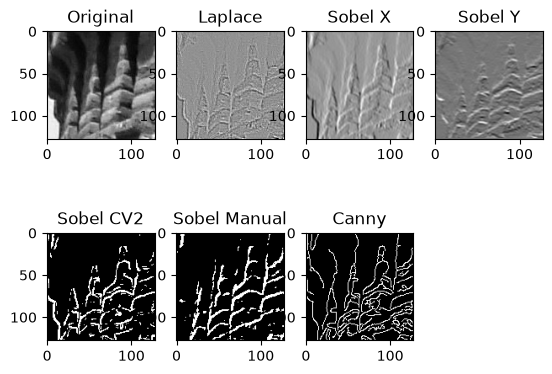

In [103]:

    

original_image = cv2.imread("img/patch02.jpg", cv2.IMREAD_GRAYSCALE)
assert original_image is not None, "Image not found"

img: list[cv2.typing.MatLike] = []
for i in range(6):
    img.append(original_image.copy())


conf, figura = plt.subplots(2, 4)
figura[0, 0].imshow(img[0], cmap='grey')
figura[0, 0].set_title("Original")

figura[0, 1].imshow(laplace(img[1]), cmap='grey')
figura[0, 1].set_title("Laplace")

figura[0, 2].imshow(sobel_x(img[2]),cmap='grey')
figura[0, 2].set_title("Sobel X")

figura[0, 3].imshow(sobel_y(img[3]), cmap='grey')
figura[0, 3].set_title("Sobel Y")

figura[1, 0].imshow(sobel_limiar_implemented(img[3], 70), cmap='grey')
figura[1, 0].set_title("Sobel CV2")

figura[1, 1].imshow(sobel_limiar(img[4], 133.5), cmap='grey')
figura[1, 1].set_title("Sobel Manual")

figura[1, 2].imshow(canny_detect(img[5], 30, 150), cmap='grey')
figura[1, 2].set_title("Canny")

figura[1, 3].set_visible(False)

## 3B

In [49]:
chessboards = []
answers = []

for file in os.listdir("./img"):
    if "chessboard" in file:
        chessboards.append("./img/" + file)
        if file == "chessboard.png":
            answers.append(0)
        else:
            pera = file.replace("chessboard", "")
            pera2 = pera.replace(".png", "")
            answers.append(pera2)

for i in range(len(chessboards)):
    print("name of the file: " + str(chessboards[i]))
    print("angle: " + str(answers[i]))

t = 1.0 # limiar!

"""basicamente eu preciso calcular os limiares e os angulos em tipo todos os pixels
os que forem suficientemente longe de 0 sao considerados
eu posso pegar a moda de todos eles"""



name of the file: ./img/chessboard48.png
angle: 48
name of the file: ./img/chessboard12.png
angle: 12
name of the file: ./img/chessboard85.png
angle: 85
name of the file: ./img/chessboard.png
angle: 0
name of the file: ./img/chessboard73.png
angle: 73
name of the file: ./img/chessboard25.png
angle: 25


'basicamente eu preciso calcular os limiares e os angulos em tipo todos os pixels\nos que forem suficientemente longe de 0 sao considerados\neu posso pegar a moda de todos eles'

In [57]:
x = np.array([-1, +1, +1, -1])
y = np.array([-1, -1, +1, +1])
print(np.arctan2(y, x) * 180 / np.pi)

[-135.  -45.   45.  135.]


In [ ]:

for i in range(len(chessboards)):
    if i != 0:
        continue
    img = cv2.imread(chessboards[i], flags=cv2.IMREAD_GRAYSCALE)
    dx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
    dy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

    gradient = np.zeros(dx.shape) # lowkey nao preciso definir isso aq porque eh so calcular em O(1)

    angles = np.arctan2(dy, dx) * 180 / np.pi;
    print(np.max(angles))

    print(np.unique(angles))

    # print(angles)

    # se as intensidades forem maiores do que uma intensidade a gente considera

    angulos = []

    print(np.min(dx))
    print(np.max(dx))
    print(np.min(dy))
    print(np.max(dy))

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if (np.sqrt(dx[i][j]**2 + dy[i][j]**2) > t):
                angulos.append(angles[i][j])

    angulos.sort()

    # print(len(angulos))

    # print(np.max(angulos))

    # print(angulos)

    # for i in range(len(angulos)):
    #     print(angulos[i])
    

    # print(angulos)

    # print(angulos[len(angulos)/2])

    


            


180.0
[-179.88993689 -179.70164934 -179.01821278 ...  179.09061955  179.6540152
  180.        ]
-10979.0
10979.0
-10795.0
10795.0
